# **Predicción del Sistema Operativo de un Usuario a Partir de su Comportamiento Digital**

Este dataset registra el comportamiento de usuarios en una plataforma digital, donde cada fila representa una sesión de navegación. El objetivo es predecir qué sistema operativo usa el usuario

## Funciones

In [7]:
# Función imputación de outlier
# ------

def imputar_valores_extremos(df, variable, metodo='media'):
    """
    Imputa valores extremos en una variable de un DataFrame utilizando la media o la mediana.

    Parámetros:
    df (DataFrame): El DataFrame que contiene la variable a imputar.
    variable (str): El nombre de la variable que deseas imputar.
    metodo (str): La forma de imputación ('media' o 'mediana'). Por defecto es 'media'.

    Retorna:
    DataFrame: El DataFrame con la variable imputada.
    """
    if metodo not in ['media', 'mediana']:
        raise ValueError("El método debe ser 'media' o 'mediana'")

    # Calcular la media o la mediana
    if metodo == 'media':
        valor_imputacion = df[variable].mean()
    else:
        valor_imputacion = df[variable].median()

    # Identificar valores extremos (usando una regla de 3 veces la desviación estándar)
    limite_inferior = df[variable].mean() - 1.9 * df[variable].std()
    limite_superior = df[variable].mean() + 1.9 * df[variable].std()

    # Imputar valores extremos
    df[variable] = np.where(
        (df[variable] < limite_inferior) | (df[variable] > limite_superior),
        valor_imputacion,
        df[variable]
    )

    return df


# Función imputación perdidos
# ------

def imputar_valores(df, variable, metodo='media', valor_especifico=None):
    """
    Imputa valores perdidos en una columna de un DataFrame según el método especificado.

    Parámetros:
    df (pd.DataFrame): El DataFrame en el que se imputarán los valores.
    variable (str): El nombre de la columna a imputar.
    metodo (str): El método de imputación ('media', 'mediana', 'moda', 'valor_especifico').
    valor_especifico: El valor específico a usar para la imputación (relevante solo si 'metodo' es 'valor_especifico').

    Retorna:
    pd.DataFrame: El DataFrame con la variable imputada.
    """

    if metodo == 'media':
        imputacion = df[variable].mean()
    elif metodo == 'mediana':
        imputacion = df[variable].median()
    elif metodo == 'moda':
        imputacion = df[variable].mode()[0]
    elif metodo == 'valor_especifico':
        if valor_especifico is None:
            raise ValueError("Debe proporcionar un valor específico para la imputación.")
        imputacion = valor_especifico
    else:
        raise ValueError("Método de imputación no reconocido. Use 'media', 'mediana', 'moda' o 'valor_especifico'.")

    df[variable].fillna(imputacion, inplace=True)
    return df


def calcular_valores_perdidos(df):
    """
    Calcula la cantidad y el porcentaje de valores NaN en cada variable del DataFrame.

    Parámetros:
    df (pd.DataFrame): DataFrame con las variables a analizar.

    Retorna:
    pd.DataFrame: Un DataFrame con el resumen de valores perdidos, mostrando:
        - Variable: Nombre de la columna analizada.
        - Total: Cantidad total de filas en la variable.
        - Valores Perdidos: Cantidad de valores NaN en la variable.
        - % Valores Perdidos: Porcentaje de valores NaN respecto al total (con 2 decimales).
    """
    resumen_perdidos = []  # Lista para almacenar los resultados

    for col in df.columns:  # Analizar todas las columnas
        total = df[col].shape[0]  # Total de filas en la columna
        valores_perdidos = df[col].isna().sum()  # Conteo de valores NaN

        # Calcular el porcentaje de valores perdidos
        porcentaje_perdidos = (valores_perdidos / total) * 100 if total > 0 else 0

        # Agregar la información a la lista de resultados
        resumen_perdidos.append([col, total, valores_perdidos, f"{porcentaje_perdidos:.2f}%"])

    # Convertir la lista en un DataFrame
    df_resumen = pd.DataFrame(resumen_perdidos, columns=['Variable', 'Total', 'Valores Perdidos', '% Valores Perdidos'])

    return df_resumen



# Funcion graficadora confusion_marix
# ---
def confusion_matrix_graph(cm):
  plt.figure(figsize=(8, 6))
  sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
              xticklabels=['No', 'Yes'],
              yticklabels=['No', 'Yes'])
  plt.title('Matriz de Confusión')
  plt.xlabel('Predicción')
  plt.ylabel('Realidad')
  plt.show()


In [ ]:
%pip install pandas==1.5.3
%pip install numpy==1.23.5
%pip install seaborn==0.12.2
%pip install matplotlib==3.7.0
%pip install scikit-learn==1.2.1
%pip install missingno==0.5.2

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


## Carga de datos


In [9]:
#Importamos las librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc
from collections import Counter

In [21]:
# Creando conexión con google drive
#from google.colab import drive
#drive.mount('/gdrive')

In [22]:
#Importamos la data
#data = pd.read_csv('/gdrive/MyDrive/03. CURSOS/06. DMC - ADVANCED DATA SCIENCE/03. Aprendizaje supervisado multiclase/clase 02/usuarios_win_mac_lin_exp_cmp.csv', encoding='latin1', sep = ';')
#data.head()
data= pd.read_csv('../data/raw/usuarios_win_mac_lin_exp_cmp.csv', encoding='latin1', sep = ';')
data.head()

,duracion,paginas,acciones,valor,clase,hora_dia,pais,edad,experiencia,navegador,nivel_usuario
0,7.0,2,4,8,2,noche,Chile,25.645123,media,Firefox,4.394008
1,21.0,2,6,6,2,tarde,España,55.488254,alta,Chrome,2.887318
2,57.0,2,4,4,2,mañana,Argentina,30.551096,alta,Safari,2.609819
3,101.0,3,6,12,2,noche,USA,37.965528,media,Firefox,2.214545
4,109.0,2,6,12,2,tarde,España,57.256667,alta,Chrome,3.040157


In [23]:
data.columns

Index(['duracion', 'paginas', 'acciones', 'valor', 'clase', 'hora_dia', 'pais',
       'edad', 'experiencia', 'navegador', 'nivel_usuario'],
      dtype='object')

# Diccionario de Variables — Dataset de Comportamiento Digital por Sistema Operativo

| **Variable**       | **Descripción** |
|--------------------|-----------------|
| **duracion**       | Tiempo total (en segundos) que el usuario permaneció realizando la actividad durante la sesión. |
| **paginas**        | Número total de páginas o secciones visitadas por el usuario. |
| **acciones**       | Cantidad de acciones realizadas (clics, formularios, descargas, interacciones, etc.). |
| **valor**          | Valor de la sesión según su relevancia o nivel de conversión. |
| **clase**          | **Variable objetivo** (sistema operativo utilizado):<br>**0 = Windows**, **1 = Macintosh**, **2 = Linux**. |
| **hora_dia**       | Hora del día (0–23) en que ocurre la actividad del usuario. |
| **pais**           | País desde el cual se registró la interacción. |
| **edad**           | Edad del usuario en años. |
| **experiencia**    | Nivel de experiencia tecnológica del usuario (escala sugerida: 1 = baja, 5 = alta). |
| **navegador**      | Navegador web utilizado (Chrome, Firefox, Edge, Safari, etc.). |
| **nivel_usuario**  | Nivel del usuario según su clasificación interna (por ejemplo: básico, intermedio, avanzado). |

---

In [ ]:
# Desarrollar un modelo predictivo para detectar la fuga de clientes de una empresa de telecomunicaciones

# y (variable dependiente) : Churn
# Xs (variables independientes) : Todas menos el Churn, CustomerID

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1230 entries, 0 to 1229
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   duracion       1144 non-null   float64
 1   paginas        1230 non-null   int64  
 2   acciones       1230 non-null   int64  
 3   valor          1230 non-null   int64  
 4   clase          1230 non-null   int64  
 5   hora_dia       1144 non-null   object 
 6   pais           1230 non-null   object 
 7   edad           1230 non-null   float64
 8   experiencia    1230 non-null   object 
 9   navegador      1230 non-null   object 
 10  nivel_usuario  1230 non-null   float64
dtypes: float64(3), int64(4), object(4)
memory usage: 105.8+ KB


In [ ]:
data.duplicated().sum() #data.drop_duplicated() esta funcion elimina las filas duplicadas de mi dataset

np.int64(0)

#### Análisis descriptivo de Clase


In [25]:
data["clase"].value_counts(normalize = True) * 100 # Diferencia de 66.66666% y 33.333333%

0    50.243902
2    26.341463
1    23.414634
Name: clase, dtype: float64

In [26]:
# Crear el gráfico
ax = sns.catplot(x='clase', kind='count', data=data)
total = len(data) # Obtener el total de datos
# Agregar etiquetas con porcentaje y valor absoluto
for p in ax.ax.patches:
    count = int(p.get_height())  # Valor absoluto
    percentage = f"{(count / total) * 100:.1f}%"  # Porcentaje con 1 decimal
    ax.ax.text(p.get_x() + p.get_width() / 2, p.get_height(),
               f"{percentage}, ({count})",
               ha='center', va='bottom', fontsize=12, fontweight='bold')
plt.show()

In [27]:
# Modelos de Clasificación

# 1. Limpieza de tu data
# 2. Analisis Descriptivo
# 3. Organizar tu data a formato numerico (variables cualitativas --> numericas (formato))
# 4. Particion de la data (train y test)
# 5. Ejecucion de modelos
# 6. Balanceo de datos
# 7. Optimizacion de hiperparametros

#### Limpieza de datos


In [29]:
# Separando las variables segun su tipo para un correcta lectura

# Lista de variables numéricas
numeric_vars = data.select_dtypes(include=['number']).columns.tolist()

# Lista de variables categóricas
categorical_vars = data.select_dtypes(include=['object', 'category']).columns.tolist()


In [30]:
numeric_vars

['duracion', 'paginas', 'acciones', 'valor', 'clase', 'edad', 'nivel_usuario']

In [31]:
categorical_vars

['hora_dia', 'pais', 'experiencia', 'navegador']

##### Analizando variables numéricas

In [32]:
data.describe() # describe es una funcion para tener un reporte estadistico basico rapidamente

,duracion,paginas,acciones,valor,clase,edad,nivel_usuario
count,1144.000000,1230.000000,1230.000000,1230.000000,1230.000000,1230.000000,1230.000000
mean,109.382253,2.082114,8.738211,31.621951,0.760976,43.558459,2.991249
std,201.289770,1.527802,9.180839,41.492529,0.842198,15.179240,1.425953
min,1.000000,1.000000,1.000000,1.000000,0.000000,5.019250,-1.271788
25%,11.000000,1.000000,3.000000,7.000000,0.000000,31.000000,2.000000
50%,13.000000,2.000000,6.000000,19.000000,0.000000,43.983275,3.000000
75%,109.250000,2.000000,10.750000,38.000000,2.000000,56.000000,4.000000
max,1117.000000,11.000000,77.000000,398.000000,2.000000,89.157211,6.960731


In [33]:
# Generar histogramas para todas las variables numéricas
for col in numeric_vars:
    plt.figure(figsize=(6,4))
    plt.hist(data[col], bins=30, edgecolor='black')
    plt.title(f"Distribución de {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.grid(alpha=0.3)
    plt.show()

Viendo presencia de valores extremos

In [34]:
# Función para detectar valores atípicos con el método IQR
def detectar_outliers(df):
    resumen = {}
    for col in df.select_dtypes(include=['number']):  # Solo columnas numéricas
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
        porcentaje_outliers = (len(outliers) / len(df)) * 100

        resumen[col] = f"{porcentaje_outliers:.1f}% ({len(outliers)} valores atípicos)"

    return resumen

In [35]:
# Aplicar la función al DataFrame
outliers_resumen = detectar_outliers(data)

# Mostrar resultados
for variable, resumen in outliers_resumen.items():
    print(f"{variable}: {resumen}")

duracion: 12.9% (159 valores atípicos)
paginas: 14.6% (179 valores atípicos)
acciones: 8.0% (99 valores atípicos)
valor: 7.6% (94 valores atípicos)
clase: 0.0% (0 valores atípicos)
edad: 0.0% (0 valores atípicos)
nivel_usuario: 0.1% (1 valores atípicos)


In [36]:
# Imputando variables con presencia de valores atípicos
# ----

data['acciones_imput'] = data['acciones']

# Imputar valores extremos en la columna 'variable1' usando la media
data = imputar_valores_extremos(data, 'acciones_imput', metodo='mediana')

In [37]:
# Aplicar la función al DataFrame
outliers_resumen = detectar_outliers(data)

# Mostrar resultados
for variable, resumen in outliers_resumen.items():
    print(f"{variable}: {resumen}")

duracion: 12.9% (159 valores atípicos)
paginas: 14.6% (179 valores atípicos)
acciones: 8.0% (99 valores atípicos)
valor: 7.6% (94 valores atípicos)
clase: 0.0% (0 valores atípicos)
edad: 0.0% (0 valores atípicos)
nivel_usuario: 0.1% (1 valores atípicos)
acciones_imput: 7.2% (89 valores atípicos)


In [38]:
from scipy.stats import skew, kurtosis

In [39]:
# Calcular asimetría y curtosis antes y después de la imputación
skew_original = skew(data['acciones'], nan_policy='omit')
kurt_original = kurtosis(data['acciones'], nan_policy='omit')

skew_imput = skew(data['acciones_imput'], nan_policy='omit')
kurt_imput = kurtosis(data['acciones_imput'], nan_policy='omit')

# Crear gráfico de distribución comparativo
plt.figure(figsize=(10, 5))
sns.kdeplot(data['acciones'], label='Original', fill=True, color='blue', alpha=0.5)
sns.kdeplot(data['acciones_imput'], label='Imputada', fill=True, color='red', alpha=0.5)

plt.xlabel('Valor de acciones')
plt.ylabel('Densidad')
plt.title('Comparación de Distribuciones: Original vs Imputada')
plt.legend()
plt.show()

# Mostrar métricas
print(f"Asimetría Original: {skew_original:.4f}, Curtosis Original: {kurt_original:.4f}")
print(f"Asimetría Imputada: {skew_imput:.4f}, Curtosis Imputada: {kurt_imput:.4f}")

Asimetría Original: 2.6535, Curtosis Original: 10.1172
Asimetría Imputada: 1.4382, Curtosis Imputada: 1.4327


In [40]:
numeric_vars.remove('acciones')
numeric_vars.append('acciones_imput')
numeric_vars

['duracion',
 'paginas',
 'valor',
 'clase',
 'edad',
 'nivel_usuario',
 'acciones_imput']

##### Analizando variables categóricas

In [41]:
# Iterar sobre las columnas del DataFrame
for column in data.columns:
  if data[column].dtype == 'object' or data[column].dtype.name == 'category':
    print(f"Resumen de porcentajes para la variable '{column}':\n")
    print(data[column].value_counts(normalize=True) * 100)
    print("\n" + "-"*50 + "\n")

Resumen de porcentajes para la variable 'hora_dia':

mañana    34.790210
tarde     34.090909
noche     31.118881
Name: hora_dia, dtype: float64

--------------------------------------------------

Resumen de porcentajes para la variable 'pais':

España       21.788618
USA          21.382114
Mexico       20.975610
Chile        18.943089
Argentina    16.910569
Name: pais, dtype: float64

--------------------------------------------------

Resumen de porcentajes para la variable 'experiencia':

alta     34.308943
baja     33.414634
media    32.276423
Name: experiencia, dtype: float64

--------------------------------------------------

Resumen de porcentajes para la variable 'navegador':

Firefox    26.341463
Safari     25.040650
Edge       24.796748
Chrome     23.821138
Name: navegador, dtype: float64

--------------------------------------------------



##### Mostrando presencia de valores perdidos

In [42]:
calcular_valores_perdidos(data)

,Variable,Total,Valores Perdidos,% Valores Perdidos
0,duracion,1230,86,6.99%
1,paginas,1230,0,0.00%
2,acciones,1230,0,0.00%
3,valor,1230,0,0.00%
4,clase,1230,0,0.00%
5,hora_dia,1230,86,6.99%
6,pais,1230,0,0.00%
7,edad,1230,0,0.00%
8,experiencia,1230,0,0.00%
9,navegador,1230,0,0.00%


In [43]:
import missingno as msno # librería para tratamiento de datos perdidos

ModuleNotFoundError: No module named 'missingno'

<Axes: >

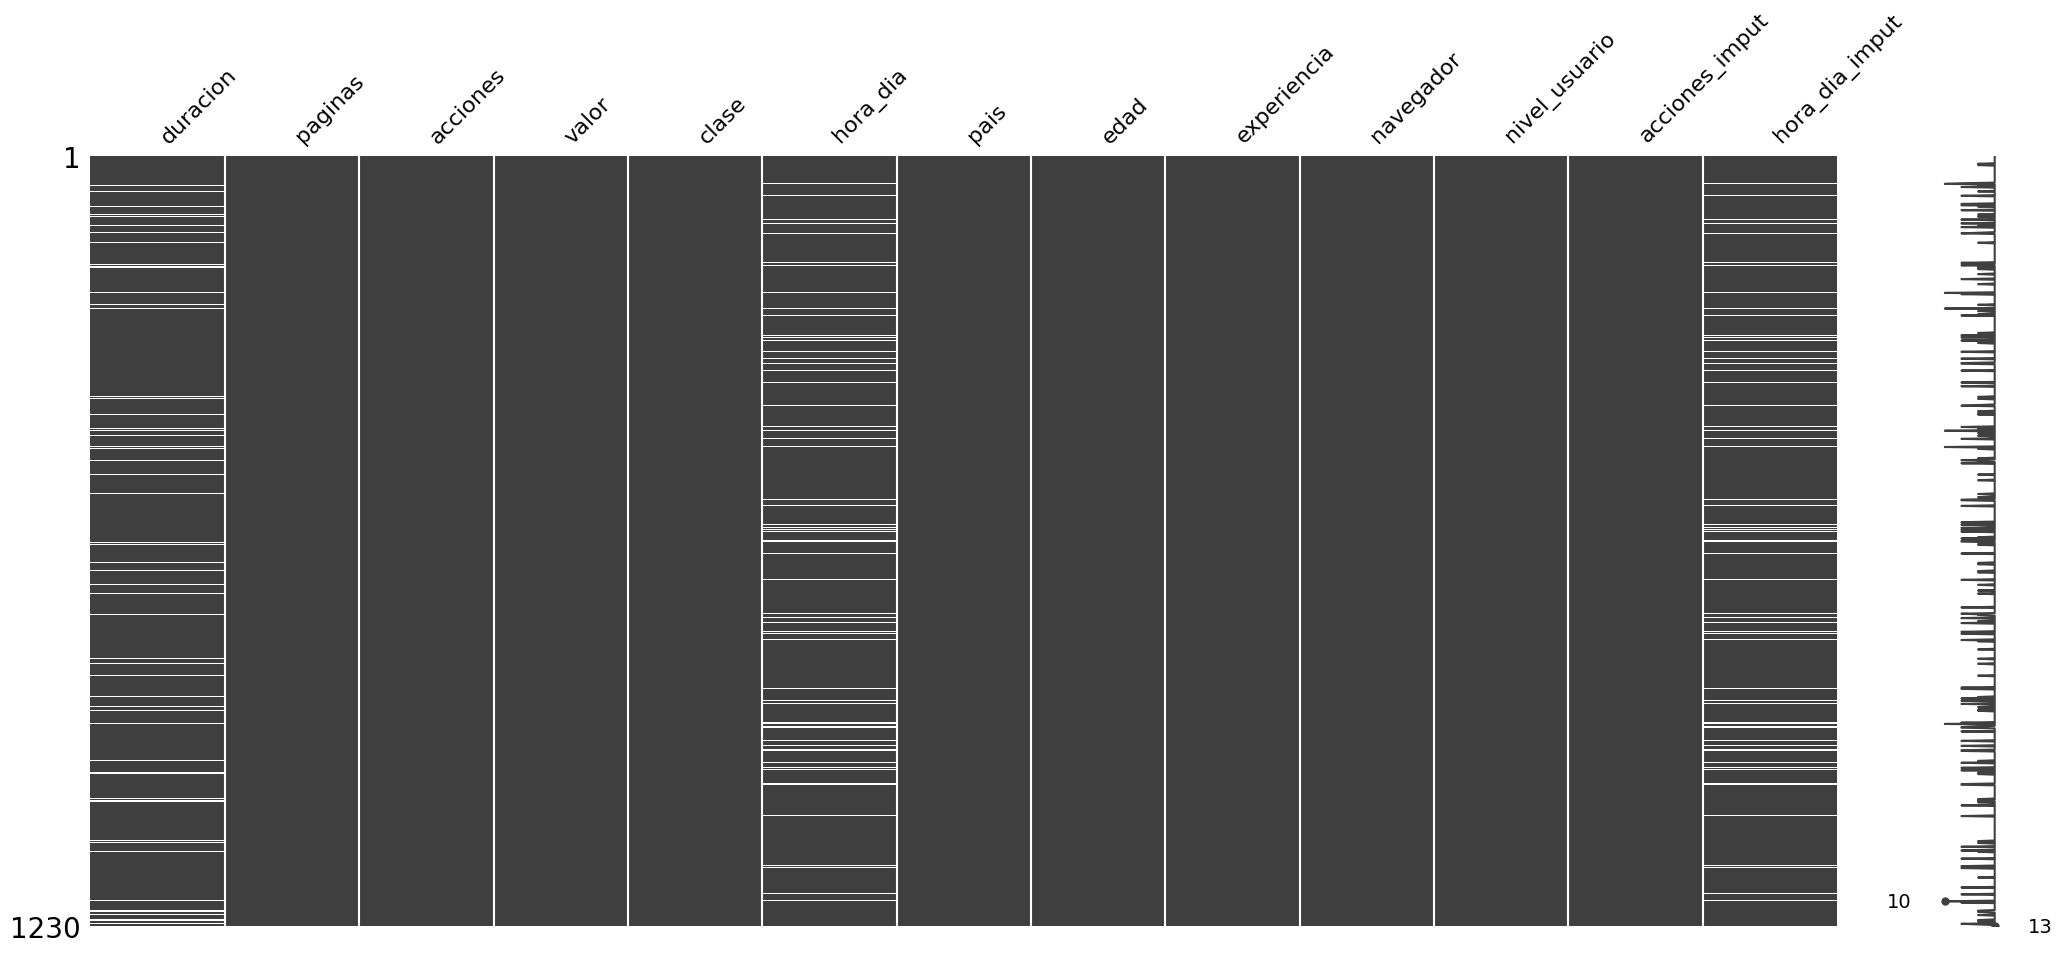

In [ ]:
msno.matrix(data)

Imputando valores en datos faltantes

In [ ]:
data['hora_dia_imput'] = data['hora_dia']

In [ ]:
data.head()

,duracion,paginas,acciones,valor,clase,hora_dia,pais,edad,experiencia,navegador,nivel_usuario,acciones_imput,hora_dia_imput
0,7.0,2,4,8,2,noche,Chile,25.645123,media,Firefox,4.394008,4.0,noche
1,21.0,2,6,6,2,tarde,España,55.488254,alta,Chrome,2.887318,6.0,tarde
2,57.0,2,4,4,2,mañana,Argentina,30.551096,alta,Safari,2.609819,4.0,mañana
3,101.0,3,6,12,2,noche,USA,37.965528,media,Firefox,2.214545,6.0,noche
4,109.0,2,6,12,2,tarde,España,57.256667,alta,Chrome,3.040157,6.0,tarde


In [ ]:
data = imputar_valores(data,'hora_dia_imput',metodo='moda')

/tmp/ipython-input-3040614116.py:69: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[variable].fillna(imputacion, inplace=True)


In [ ]:
calcular_valores_perdidos(data)

,Variable,Total,Valores Perdidos,% Valores Perdidos
0,duracion,1230,86,6.99%
1,paginas,1230,0,0.00%
2,acciones,1230,0,0.00%
3,valor,1230,0,0.00%
4,clase,1230,0,0.00%
5,hora_dia,1230,86,6.99%
6,pais,1230,0,0.00%
7,edad,1230,0,0.00%
8,experiencia,1230,0,0.00%
9,navegador,1230,0,0.00%


In [ ]:
categorical_vars.remove('hora_dia')
categorical_vars.append('hora_dia_imput')
categorical_vars

['pais', 'experiencia', 'navegador', 'hora_dia_imput']

In [ ]:
data['duracion_imput'] = data['duracion'].fillna(data['duracion'].mean()) # Imputando los valores perdidos por la media
data['duracion_imput_2'] = data['duracion'].fillna(data['duracion'].median()) # Imputando los valores perdidos por la mediana
data['duracion_imput_3'] = data['duracion'].fillna(data['duracion'].mode()[0]) # Imputando los valores perdidos por la moda

In [ ]:
calcular_valores_perdidos(data)

,Variable,Total,Valores Perdidos,% Valores Perdidos
0,duracion,1230,86,6.99%
1,paginas,1230,0,0.00%
2,acciones,1230,0,0.00%
3,valor,1230,0,0.00%
4,clase,1230,0,0.00%
5,hora_dia,1230,86,6.99%
6,pais,1230,0,0.00%
7,edad,1230,0,0.00%
8,experiencia,1230,0,0.00%
9,navegador,1230,0,0.00%


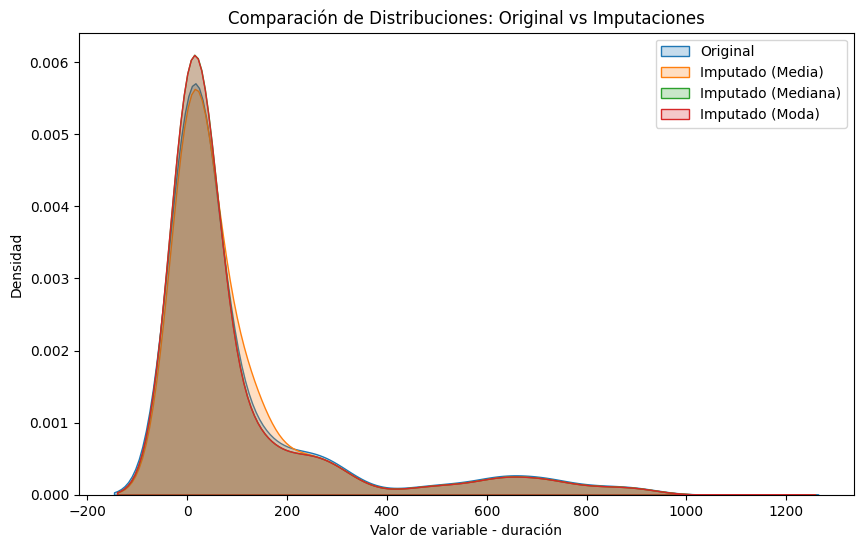

             Variable  Asimetría  Curtosis
0            Original   2.421640  5.134245
1    Imputado (Media)   2.511014  5.745736
2  Imputado (Mediana)   2.546809  5.819699
3     Imputado (Moda)   2.545966  5.815591


In [ ]:
# Lista de variables a analizar
variables = {
    'Original': data['duracion'].dropna(),  # Eliminar NaN antes de calcular métricas
    'Imputado (Media)': data['duracion_imput'],
    'Imputado (Mediana)': data['duracion_imput_2'],
    'Imputado (Moda)': data['duracion_imput_3']
}

# Crear la figura del gráfico
plt.figure(figsize=(10, 6))

for label, datx in variables.items():
    sns.kdeplot(datx, label=label, fill=True)

plt.legend()
plt.title("Comparación de Distribuciones: Original vs Imputaciones")
plt.xlabel("Valor de variable - duración")
plt.ylabel("Densidad")
plt.show()

# Crear tabla con métricas de asimetría y curtosis
metricas = []
for label, datx in variables.items():
    metricas.append([label, skew(datx, nan_policy='omit'), kurtosis(datx, nan_policy='omit')])

df_metricas = pd.DataFrame(metricas, columns=['Variable', 'Asimetría', 'Curtosis'])
print(df_metricas)

In [ ]:
data

,duracion,paginas,acciones,valor,clase,hora_dia,pais,edad,experiencia,navegador,nivel_usuario,acciones_imput,hora_dia_imput,duracion_imput,duracion_imput_2,duracion_imput_3
0,7.0,2,4,8,2,noche,Chile,25.645123,media,Firefox,4.394008,4.0,noche,7.000000,7.0,7.0
1,21.0,2,6,6,2,tarde,España,55.488254,alta,Chrome,2.887318,6.0,tarde,21.000000,21.0,21.0
2,57.0,2,4,4,2,mañana,Argentina,30.551096,alta,Safari,2.609819,4.0,mañana,57.000000,57.0,57.0
3,101.0,3,6,12,2,noche,USA,37.965528,media,Firefox,2.214545,6.0,noche,101.000000,101.0,101.0
4,109.0,2,6,12,2,tarde,España,57.256667,alta,Chrome,3.040157,6.0,tarde,109.000000,109.0,109.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1225,12.0,1,5,13,0,NaN,Chile,66.000000,alta,Chrome,5.000000,5.0,mañana,12.000000,12.0,12.0
1226,NaN,1,7,47,1,mañana,Chile,48.000000,alta,Safari,5.000000,7.0,mañana,109.382253,13.0,11.0
1227,12.0,1,3,6,2,mañana,Mexico,33.000000,alta,Edge,5.000000,3.0,mañana,12.000000,12.0,12.0
1228,11.0,1,4,6,2,mañana,Chile,28.000000,baja,Safari,4.000000,4.0,mañana,11.000000,11.0,11.0


Imputación por métodos multivariados

Para imputar la variable lights usando IterativeImputer, es importante elegir variables que estén correlacionadas con lights y puedan ayudar a estimar sus valores.

Basándonos en las relaciones de consumo energético, las posibles opciones de variables que podrían explicar lights son:

- paginas: Cuantas más páginas visita alguien, más tiempo suele durar la sesión.
- acciones: A mayor interacción → mayor duración. Captura muy bien comportamientos de usuarios intensivos.
- nivel_usuario: Usuarios avanzados suelen pasar más tiempo explorando.
- valor: Los usuarios que generan valor (compras, conversiones, engagement) tienden a tener sesiones más largas.

In [ ]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

In [ ]:
# Selección de variables para la imputación
vars_imputacion = ['duracion', 'paginas', 'acciones_imput', 'nivel_usuario', 'valor']

df_imputacion = data[vars_imputacion] # Filtrar solo las columnas necesarias
imputer = IterativeImputer(random_state=42) # Crear el imputador con un modelo base (ejemplo: regresión bayesiana)

# Aplicar la imputación
df_imputado = imputer.fit_transform(df_imputacion)
df_imputado = pd.DataFrame(df_imputado, columns=vars_imputacion)
data['duracion_imput_4'] = df_imputado['duracion']

In [ ]:
calcular_valores_perdidos(data)

,Variable,Total,Valores Perdidos,% Valores Perdidos
0,duracion,1230,86,6.99%
1,paginas,1230,0,0.00%
2,acciones,1230,0,0.00%
3,valor,1230,0,0.00%
4,clase,1230,0,0.00%
5,hora_dia,1230,86,6.99%
6,pais,1230,0,0.00%
7,edad,1230,0,0.00%
8,experiencia,1230,0,0.00%
9,navegador,1230,0,0.00%


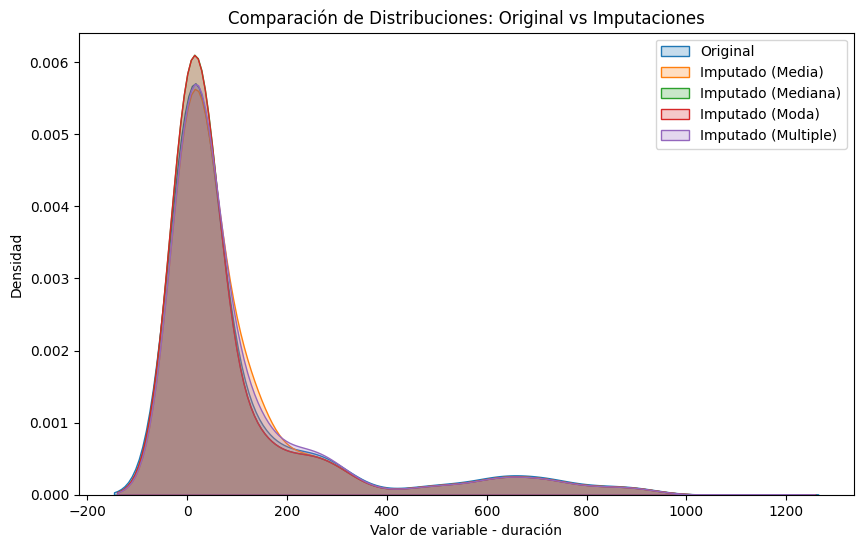

              Variable  Asimetría  Curtosis
0             Original   2.421640  5.134245
1     Imputado (Media)   2.511014  5.745736
2   Imputado (Mediana)   2.546809  5.819699
3      Imputado (Moda)   2.545966  5.815591
4  Imputado (Multiple)   2.486468  5.624627


In [ ]:
# Lista de variables a analizar
variables = {
    'Original': data['duracion'].dropna(),  # Eliminar NaN antes de calcular métricas
    'Imputado (Media)': data['duracion_imput'],
    'Imputado (Mediana)': data['duracion_imput_2'],
    'Imputado (Moda)': data['duracion_imput_3'],
    'Imputado (Multiple)': data['duracion_imput_4']
}

# Crear la figura del gráfico
plt.figure(figsize=(10, 6))

for label, datx in variables.items():
    sns.kdeplot(datx, label=label, fill=True)

plt.legend()
plt.title("Comparación de Distribuciones: Original vs Imputaciones")
plt.xlabel("Valor de variable - duración")
plt.ylabel("Densidad")
plt.show()

# Crear tabla con métricas de asimetría y curtosis
metricas = []
for label, datx in variables.items():
    metricas.append([label, skew(datx, nan_policy='omit'), kurtosis(datx, nan_policy='omit')])

df_metricas = pd.DataFrame(metricas, columns=['Variable', 'Asimetría', 'Curtosis'])
print(df_metricas)

In [ ]:
numeric_vars.remove('duracion')
numeric_vars.append('duracion_imput_4')
numeric_vars

ValueError: list.remove(x): x not in list

## Preprocesamiento de datos

In [ ]:
numeric_vars.remove('clase')

# Guardar todas las variables categoricas en un solo lugar
cat_cols = data[categorical_vars]
num_cols = data[numeric_vars]

# Generar variables para las dos columnas que omiti de mi mapeo de variables cualitativas y cuantitativas
label = data["clase"]


In [ ]:
cat_cols

,pais,experiencia,navegador,hora_dia_imput
0,Chile,media,Firefox,noche
1,España,alta,Chrome,tarde
2,Argentina,alta,Safari,mañana
3,USA,media,Firefox,noche
4,España,alta,Chrome,tarde
...,...,...,...,...
1225,Chile,alta,Chrome,mañana
1226,Chile,alta,Safari,mañana
1227,Mexico,alta,Edge,mañana
1228,Chile,baja,Safari,mañana


In [ ]:
num_cols

,paginas,valor,edad,nivel_usuario,acciones_imput,duracion_imput_4
0,2,8,25.645123,4.394008,4.0,7.000000
1,2,6,55.488254,2.887318,6.0,21.000000
2,2,4,30.551096,2.609819,4.0,57.000000
3,3,12,37.965528,2.214545,6.0,101.000000
4,2,12,57.256667,3.040157,6.0,109.000000
...,...,...,...,...,...,...
1225,1,13,66.000000,5.000000,5.0,12.000000
1226,1,47,48.000000,5.000000,7.0,61.476929
1227,1,6,33.000000,5.000000,3.0,12.000000
1228,1,6,28.000000,4.000000,4.0,11.000000


In [ ]:
# Transformacion de variables categoricas a numericas

# Label encoding (Target Encoding) : Cambiar en la misma columna el valor categorico a numerico

# Nivel_Instruccion
# -----------------
# Superior  --> 3
# Secundaria -> 2
# Tecnico. ---> 1
# Superior ---> 3
# Tecnico. ---> 1


# One hot encoding : Genera nuevas columnas dicotomicas a partir de las categorias de las variables categoricas

In [ ]:
label

,clase
0,2
1,2
2,2
3,2
4,2
...,...
1225,0
1226,1
1227,2
1228,2


In [ ]:
# Tenure, Monthly Charges y Total Charges son variables cuantitativas independientes
# Multicolinealidad : Si tienes pares de variables cuantitativas independientes correlacionadas solo debes utilizar a una
# Se elimina por un tema de eficiencia computacional
# Si las variables estan correlacionadas significa que el aporte va a ser el mismo
# Los modelos tengan una cantidad optima de variables independientes

<Axes: >

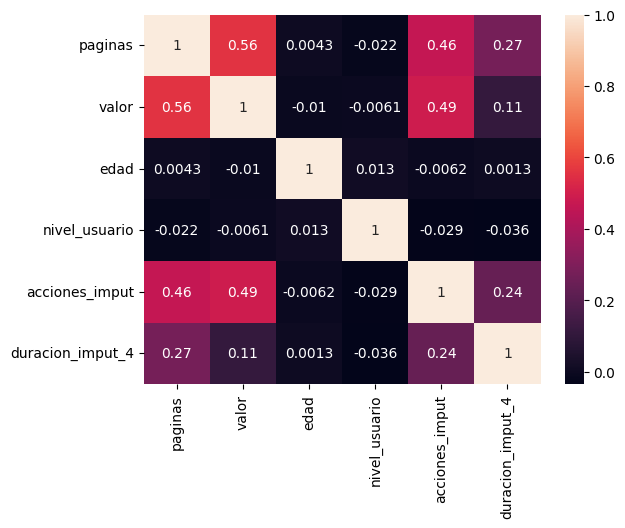

In [ ]:
# La matriz de correlacion considera el coeficiente de correlacion de Pearson
# El coeficiente de correlacion de pearson se analiza SOLO para verificar la RELACION LINEAL entre VARIABLES CUANTITATIVAS
# Si la variable tiene formato numerico pero ORIGINALMENTE es una variable CATEGORICA no aplica para la matriz de correlacion

# sns.heatmap(data.select_dtypes(include=['number']).corr(),annot=True)
sns.heatmap(data[numeric_vars].corr(),annot=True)

In [ ]:
def eta_squared(x, y):
    groups = [x[y == val] for val in np.unique(y)]
    grand_mean = x.mean()
    ss_between = sum([len(g)*(g.mean() - grand_mean)**2 for g in groups])
    ss_total = sum((x - grand_mean)**2)
    return ss_between / ss_total

In [ ]:
eta_results = {}

for col in numeric_vars:
    eta = eta_squared(data[col], data["clase"])
    eta_results[col] = eta

eta_df = pd.DataFrame({
    "Variable": list(eta_results.keys()),
    "Eta_Squared": list(eta_results.values())
}).sort_values(by="Eta_Squared", ascending=False)

eta_df

,Variable,Eta_Squared
1,valor,0.128683
4,acciones_imput,0.078407
5,duracion_imput_4,0.018308
0,paginas,0.009056
3,nivel_usuario,0.001836
2,edad,0.001343


Realizamos el proceso de one hot encoding con nuestras variables categóricas:

In [ ]:
cat_cols.head()

,pais,experiencia,navegador,hora_dia_imput
0,Chile,media,Firefox,noche
1,España,alta,Chrome,tarde
2,Argentina,alta,Safari,mañana
3,USA,media,Firefox,noche
4,España,alta,Chrome,tarde


In [ ]:
cat_cols = pd.get_dummies(data = cat_cols) #transformamos las variables categóricas a numéricas

In [ ]:
cat_cols.head()

,pais_Argentina,pais_Chile,pais_España,pais_Mexico,pais_USA,experiencia_alta,experiencia_baja,experiencia_media,navegador_Chrome,navegador_Edge,navegador_Firefox,navegador_Safari,hora_dia_imput_mañana,hora_dia_imput_noche,hora_dia_imput_tarde
0,False,True,False,False,False,False,False,True,False,False,True,False,False,True,False
1,False,False,True,False,False,True,False,False,True,False,False,False,False,False,True
2,True,False,False,False,False,True,False,False,False,False,False,True,True,False,False
3,False,False,False,False,True,False,False,True,False,False,True,False,False,True,False
4,False,False,True,False,False,True,False,False,True,False,False,False,False,False,True


In [ ]:
cat_cols.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1230 entries, 0 to 1229
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   pais_Argentina         1230 non-null   bool 
 1   pais_Chile             1230 non-null   bool 
 2   pais_España            1230 non-null   bool 
 3   pais_Mexico            1230 non-null   bool 
 4   pais_USA               1230 non-null   bool 
 5   experiencia_alta       1230 non-null   bool 
 6   experiencia_baja       1230 non-null   bool 
 7   experiencia_media      1230 non-null   bool 
 8   navegador_Chrome       1230 non-null   bool 
 9   navegador_Edge         1230 non-null   bool 
 10  navegador_Firefox      1230 non-null   bool 
 11  navegador_Safari       1230 non-null   bool 
 12  hora_dia_imput_mañana  1230 non-null   bool 
 13  hora_dia_imput_noche   1230 non-null   bool 
 14  hora_dia_imput_tarde   1230 non-null   bool 
dtypes: bool(15)
memory usage: 18.1 KB


Creamos una nueva data donde concatenamos la data original con la data que contiene las nuevas variables de one-hot-encoding:

In [ ]:
df_complete = pd.concat([num_cols, cat_cols, label], axis=1)

In [ ]:
df_complete.head()

,paginas,valor,edad,nivel_usuario,acciones_imput,duracion_imput_4,pais_Argentina,pais_Chile,pais_España,pais_Mexico,...,experiencia_baja,experiencia_media,navegador_Chrome,navegador_Edge,navegador_Firefox,navegador_Safari,hora_dia_imput_mañana,hora_dia_imput_noche,hora_dia_imput_tarde,clase
0,2,8,25.645123,4.394008,4.0,7.0,False,True,False,False,...,False,True,False,False,True,False,False,True,False,2
1,2,6,55.488254,2.887318,6.0,21.0,False,False,True,False,...,False,False,True,False,False,False,False,False,True,2
2,2,4,30.551096,2.609819,4.0,57.0,True,False,False,False,...,False,False,False,False,False,True,True,False,False,2
3,3,12,37.965528,2.214545,6.0,101.0,False,False,False,False,...,False,True,False,False,True,False,False,True,False,2
4,2,12,57.256667,3.040157,6.0,109.0,False,False,True,False,...,False,False,True,False,False,False,False,False,True,2


In [ ]:
df_complete.shape

(1230, 22)

## Particionado de datos

In [ ]:
# Al dataset o set de entrenamiento le retiramos la variable dependiente o target
X = df_complete.drop("clase",axis=1) # covariables
y = df_complete['clase'] # target

In [ ]:
from sklearn.model_selection import train_test_split

X_train_res, X_test, y_train_res, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
X_train_res.shape, y_train_res.shape

((984, 21), (984,))

In [ ]:
X_test.shape, y_test.shape

((246, 21), (246,))

In [ ]:
y_train_res

,clase
870,2
623,0
647,0
457,1
564,2
...,...
516,1
167,0
1073,0
72,0


## Balanceo de las clases de variable a predecir (Churn)

In [ ]:
# Sobremuestreo : Duplicar observaciones de la clase minoritaria para igualar la cantidad de muestras
# Submuestreo : Eliminar observaciones de la clase mayoritaria para equilibrar proporciones
# Generación sintética de muestras (SMOTE) : crear observaciones sinteticas de la clase minoritaria
# Pesos de clases : Asignan pesos distintos a las clases durante el entrenamiento para compensar el desequilibrio (class weighting)
# Ensambles de modelos : Construir ensambles que se centren mas en la clase minoritaria, como EasyEnsemble o BalanceCascade
# Tecnicas hibridas : combinar enfoques, como aplicar sobremuestreo a la clase minoritaria y submuestreo a la clase mayoritaria

Como vimos en los análisis descriptivos el % de clientes churn representaba alrededor de un 26% de la data total, lo que nos indica que existe una diferencia de alrededor del 50% con la cantidad de clientes que seguían siendo parte de la empresa, en términos de predicción es recomendable trata de crear muestras de datos que equiparen los % de distribución de ambas clases.

Hay varios métodos de muestreo que han sido diseñados para tratar datos desbalanceados, los cuales pueden ser agrupados en cuatro categorías: submuestreo, sobremuestreo, generación de datos sintéticos y aprendizaje sensible al costo. Todos estos métodos modifican la proporción de las clases y el tamaño del dataset original.

Los métodos de submuestreo eliminan observaciones de la clase mayoritaria con el fin de igualar los tamaños de las clases.

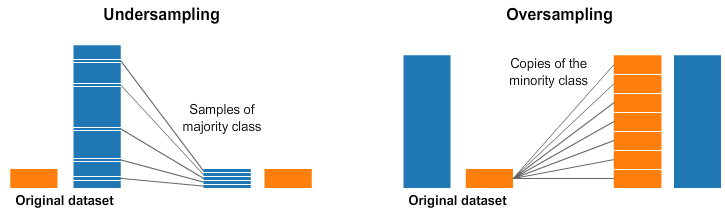

In [ ]:
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE
from collections import Counter

print("Distribución original (y_train_res):")
print(Counter(y_train_res))

Distribución original (y_train_res):
Counter({0: 494, 2: 259, 1: 231})


#### Oversampling

In [ ]:
# sampling_strategy = {
#     0: 494,   # dejas la clase 1 tal cual
#     1: 360,   # llevas la clase 2 al tamaño de la clase mayoritaria
#     2: 360    # clase 3 a 80k
# }

# oversampler = RandomOverSampler(sampling_strategy=sampling_strategy, random_state=42)
oversampler = RandomOverSampler(random_state=42)

X_train_over, y_train_over = oversampler.fit_resample(X_train_res, y_train_res)

In [ ]:
print("\nDistribución después de Oversampling:")
print(Counter(y_train_over))


Distribución después de Oversampling:
Counter({2: 494, 0: 494, 1: 494})


## Evaluación de Algoritmos

In [ ]:
# X_train_res, X_test, y_train_res, y_test

In [ ]:
# Seleccionamos el tipo de remuestreo que mejor nos beneficie
# ---------------
#X_train = X_train_res
#y_train = y_train_res

X_train = X_train_over
y_train = y_train_over


X_train.shape, y_train.shape

((1482, 21), (1482,))

In [ ]:
X_test.shape, y_test.shape

((246, 21), (246,))

Importamos las librerías de 5 tipos de algoritmos de clasificación:

1. Árboles de decisión
2. Regresión logística
3. XgBoost
4. Random forest

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
# from xgboost import XGBClassifier
import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
from sklearn import metrics
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score,roc_curve # ROC a diferencia del accuracy te da un valor justo de precision para datos desbalanceados

In [ ]:
# CURVA ROC: Grafico que muestra el rendimiento de un modelo de clasificacion en todos los umbrales donde realiza la clasificacion

# A partir del recall y precision



# AUC (Area bajo la curva) : Indicador

# PARTICION DE LA DATA (TRAIN Y TEST)

# AUC, ACCURACY, F1-SCORE (SEAN SIMILARES TANTO PARA LA DATA DE TRAIN COMO PARA LA DATA DE TEST)

# 1. METRICAS SIMILARES EN TRAIN Y TEST (BUEN AJUSTE DEL MODELO Y RESULTADOS CONSISTENTES)
# 2. METRICAS ALTAS EN TRAIN Y BAJAS EN TEST (SOBREAJUSTE - OVERFITTING)
# 3. METRICAS BAJAS EN TRAIN Y BAJAS EN TEST (SUBAJUSTE)



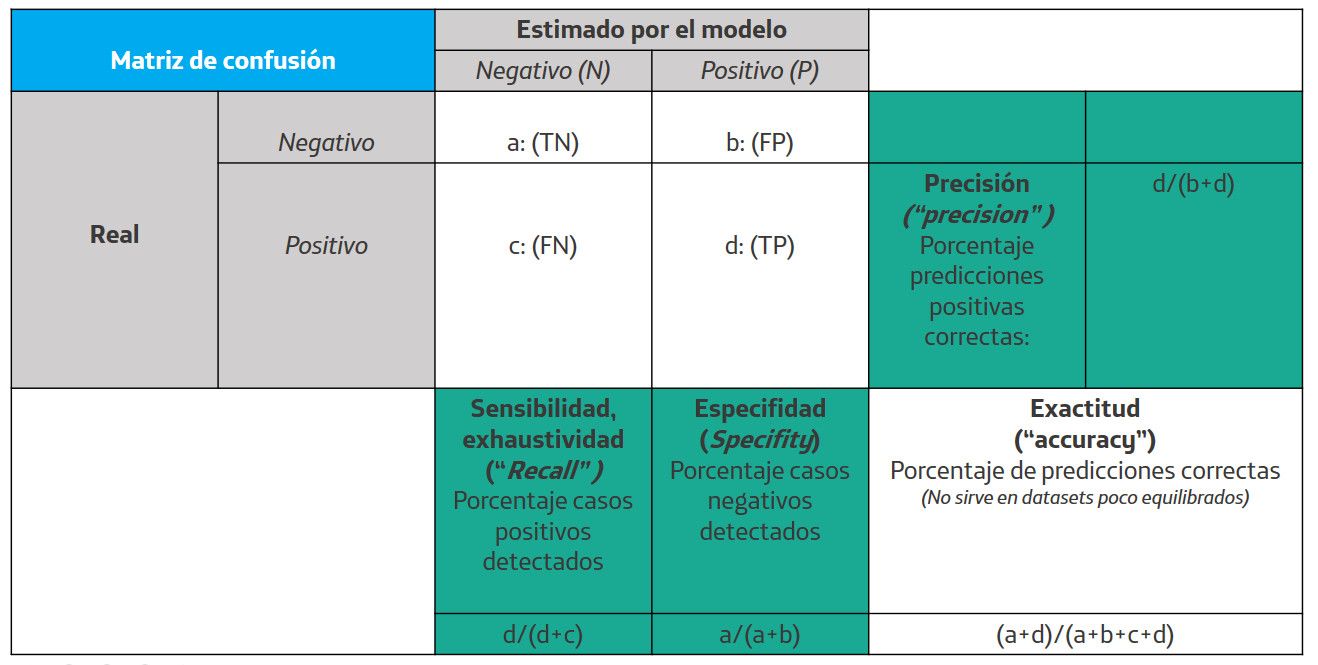

#### Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier
DT = DecisionTreeClassifier(criterion = "gini", random_state = 100,max_depth=5, min_samples_leaf=4)
# DT = DecisionTreeClassifier()

In [ ]:
DT.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, min_samples_leaf=4, random_state=100)

In [ ]:
y_train_predict_dt =  DT.predict(X_train)
y_test_predict_dt =  DT.predict(X_test)

y_train_predict_proba_dt =  DT.predict_proba(X_train)
y_test_predict_proba_dt =  DT.predict_proba(X_test)

In [ ]:
y_train_predict_dt

array([2, 0, 1, ..., 2, 2, 2])

In [ ]:
y_train_predict_proba_dt

array([[0.        , 0.        , 1.        ],
       [0.75      , 0.25      , 0.        ],
       [0.48638132, 0.51361868, 0.        ],
       ...,
       [0.06422018, 0.        , 0.93577982],
       [0.        , 0.        , 1.        ],
       [0.        , 0.        , 1.        ]])

In [ ]:
# Calcular la matriz de confusión
cm_dt = confusion_matrix(y_train, y_train_predict_dt)
cm_dt

array([[272, 181,  41],
       [ 71, 416,   7],
       [ 11,   0, 483]])


Confusion Matrix train:


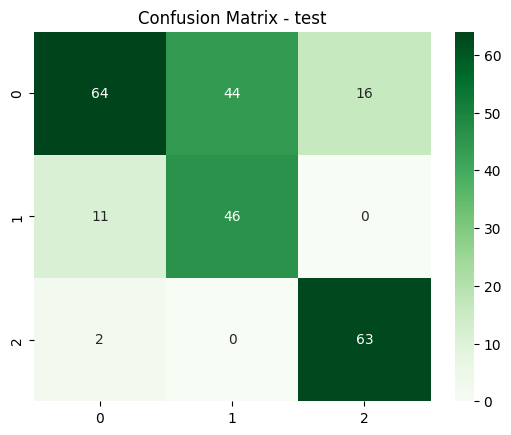

In [ ]:
print("\nConfusion Matrix train:")
sns.heatmap(confusion_matrix(y_test, y_test_predict_dt), annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix - test")
plt.show()

In [ ]:
print(metrics.classification_report(y_train,y_train_predict_dt))

              precision    recall  f1-score   support

           0       0.77      0.55      0.64       494
           1       0.70      0.84      0.76       494
           2       0.91      0.98      0.94       494

    accuracy                           0.79      1482
   macro avg       0.79      0.79      0.78      1482
weighted avg       0.79      0.79      0.78      1482



In [ ]:
print(metrics.classification_report(y_test,y_test_predict_dt))

              precision    recall  f1-score   support

           0       0.83      0.52      0.64       124
           1       0.51      0.81      0.63        57
           2       0.80      0.97      0.88        65

    accuracy                           0.70       246
   macro avg       0.71      0.76      0.71       246
weighted avg       0.75      0.70      0.70       246



#### Decision Tree - Multiclasss

One-vs-Rest (OvR)

In [ ]:
from sklearn.multiclass import OneVsRestClassifier

In [ ]:
ovr_model = OneVsRestClassifier(
    DecisionTreeClassifier(criterion="gini",random_state=100, max_depth=5,min_samples_leaf=4)
    )

In [ ]:
ovr_model.fit(X_train, y_train)

OneVsRestClassifier(estimator=DecisionTreeClassifier(max_depth=5,
                                                     min_samples_leaf=4,
                                                     random_state=100))

In [ ]:
y_train_predict_ovr = ovr_model.predict(X_train)
y_test_predict_ovr  = ovr_model.predict(X_test)

y_train_predict_proba_ovr = ovr_model.predict_proba(X_train)
y_test_predict_proba_ovr  = ovr_model.predict_proba(X_test)

In [ ]:
# Calcular la matriz de confusión
cm_dt = confusion_matrix(y_train, y_train_predict_ovr)
cm_dt

array([[360,  97,  37],
       [ 52, 435,   7],
       [  4,   1, 489]])


Confusion Matrix train:


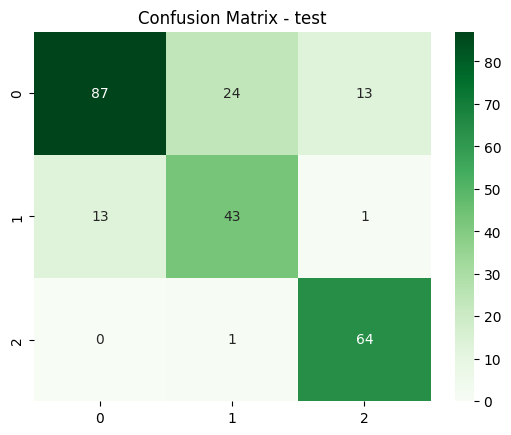

In [ ]:
print("\nConfusion Matrix train:")
sns.heatmap(confusion_matrix(y_test, y_test_predict_ovr), annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix - test")
plt.show()

In [ ]:
print(metrics.classification_report(y_train,y_train_predict_ovr))

              precision    recall  f1-score   support

           0       0.87      0.73      0.79       494
           1       0.82      0.88      0.85       494
           2       0.92      0.99      0.95       494

    accuracy                           0.87      1482
   macro avg       0.87      0.87      0.86      1482
weighted avg       0.87      0.87      0.86      1482



In [ ]:
print(metrics.classification_report(y_test,y_test_predict_ovr))

              precision    recall  f1-score   support

           0       0.87      0.70      0.78       124
           1       0.63      0.75      0.69        57
           2       0.82      0.98      0.90        65

    accuracy                           0.79       246
   macro avg       0.77      0.81      0.79       246
weighted avg       0.80      0.79      0.79       246



One-vs-One (OvO)

In [ ]:
from sklearn.multiclass import OneVsOneClassifier

In [ ]:
ovo_model = OneVsOneClassifier(
    DecisionTreeClassifier(criterion="gini", random_state=100, max_depth=5,min_samples_leaf=4)
    )

In [ ]:
ovo_model.fit(X_train, y_train)

OneVsOneClassifier(estimator=DecisionTreeClassifier(max_depth=5,
                                                    min_samples_leaf=4,
                                                    random_state=100))

In [ ]:
y_train_predict_ovo = ovo_model.predict(X_train)
y_test_predict_ovo  = ovo_model.predict(X_test)


Confusion Matrix train:


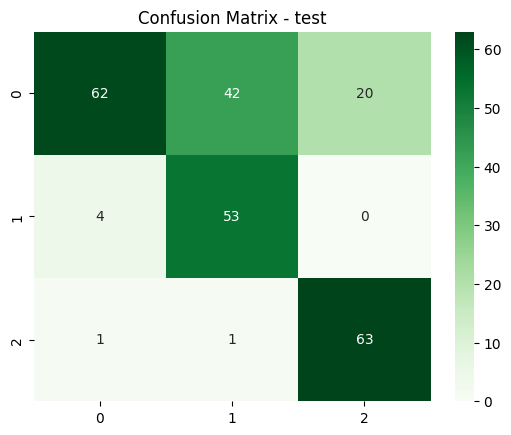

In [ ]:
print("\nConfusion Matrix train:")
sns.heatmap(confusion_matrix(y_test, y_test_predict_ovo), annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix - test")
plt.show()

In [ ]:
print(metrics.classification_report(y_train,y_train_predict_ovo))

              precision    recall  f1-score   support

           0       0.97      0.54      0.69       494
           1       0.73      0.99      0.84       494
           2       0.90      0.99      0.94       494

    accuracy                           0.84      1482
   macro avg       0.87      0.84      0.83      1482
weighted avg       0.87      0.84      0.83      1482



In [ ]:
print(metrics.classification_report(y_test,y_test_predict_ovo))

              precision    recall  f1-score   support

           0       0.93      0.50      0.65       124
           1       0.55      0.93      0.69        57
           2       0.76      0.97      0.85        65

    accuracy                           0.72       246
   macro avg       0.75      0.80      0.73       246
weighted avg       0.79      0.72      0.71       246



#### Logistic regresion

In [ ]:
LG = LogisticRegression()

In [ ]:
LG.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [ ]:
y_train_predict_lgr =  LG.predict(X_train)
y_test_predict_lgr =  LG.predict(X_test)

y_train_predict_proba_lgr =  LG.predict_proba(X_train)
y_test_predict_proba_lgr =  LG.predict_proba(X_test)

In [ ]:
# Calcular la matriz de confusión
cm_lgr = confusion_matrix(y_train, y_train_predict_lgr)
cm_lgr

array([[241, 176,  77],
       [226, 264,   4],
       [  3,   4, 487]])


Confusion Matrix train:


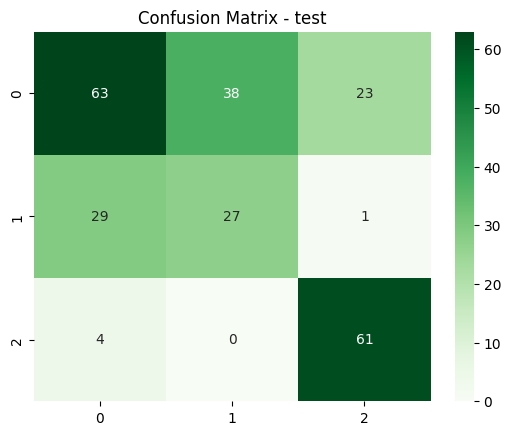

In [ ]:
print("\nConfusion Matrix train:")
sns.heatmap(confusion_matrix(y_test, y_test_predict_lgr), annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix - test")
plt.show()

In [ ]:
print(metrics.classification_report(y_train,y_train_predict_lgr))

              precision    recall  f1-score   support

           0       0.51      0.49      0.50       494
           1       0.59      0.53      0.56       494
           2       0.86      0.99      0.92       494

    accuracy                           0.67      1482
   macro avg       0.65      0.67      0.66      1482
weighted avg       0.65      0.67      0.66      1482



In [ ]:
print(metrics.classification_report(y_test,y_test_predict_lgr))

              precision    recall  f1-score   support

           0       0.66      0.51      0.57       124
           1       0.42      0.47      0.44        57
           2       0.72      0.94      0.81        65

    accuracy                           0.61       246
   macro avg       0.60      0.64      0.61       246
weighted avg       0.62      0.61      0.61       246



#### Logistic regresion - Multiclass

One-vs-Rest (OvR)

In [ ]:
# Modelo base de regresión logística
log_reg = LogisticRegression(
    multi_class='ovr',
    solver='lbfgs',
    max_iter=1000
)

# Esquema OvR
ovr_model = OneVsRestClassifier(log_reg)

In [ ]:
ovr_model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


OneVsRestClassifier(estimator=LogisticRegression(max_iter=1000,
                                                 multi_class='ovr'))

In [ ]:
y_train_predict_lgr_ovr = ovr_model.predict(X_train)
y_test_predict_lgr_ovr  = ovr_model.predict(X_test)

y_train_predict_lgr_proba_ovr = ovr_model.predict_proba(X_train)
y_test_predict_lgr_proba_ovr  = ovr_model.predict_proba(X_test)


Confusion Matrix train:


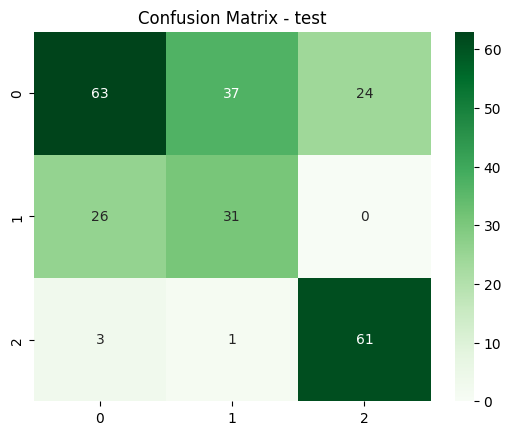

In [ ]:
print("\nConfusion Matrix train:")
sns.heatmap(confusion_matrix(y_test, y_test_predict_lgr_ovr), annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix - test")
plt.show()

In [ ]:
print(metrics.classification_report(y_train,y_train_predict_lgr_ovr))

              precision    recall  f1-score   support

           0       0.53      0.47      0.50       494
           1       0.61      0.59      0.60       494
           2       0.85      0.99      0.91       494

    accuracy                           0.68      1482
   macro avg       0.67      0.68      0.67      1482
weighted avg       0.67      0.68      0.67      1482



In [ ]:
print(metrics.classification_report(y_test,y_test_predict_lgr_ovr))

              precision    recall  f1-score   support

           0       0.68      0.51      0.58       124
           1       0.45      0.54      0.49        57
           2       0.72      0.94      0.81        65

    accuracy                           0.63       246
   macro avg       0.62      0.66      0.63       246
weighted avg       0.64      0.63      0.62       246



One-vs-One (OvO)

In [ ]:
# Modelo base de regresión logística
log_reg = LogisticRegression(
    solver='lbfgs',
    max_iter=1000
)

# Esquema OvO
ovo_model = OneVsOneClassifier(log_reg)

In [ ]:
ovo_model.fit(X_train, y_train)

OneVsOneClassifier(estimator=LogisticRegression(max_iter=1000))

In [ ]:
y_train_lgr_predict_ovo = ovo_model.predict(X_train)
y_test_lgr_predict_ovo  = ovo_model.predict(X_test)


Confusion Matrix train:


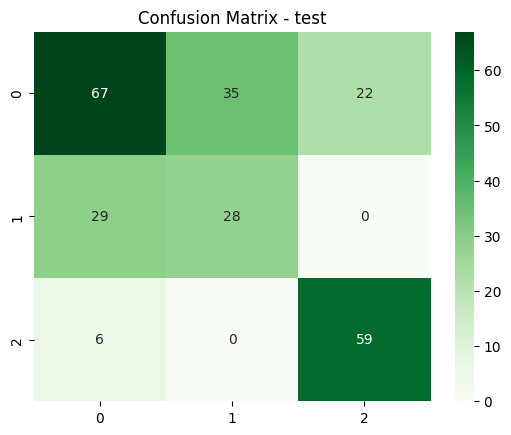

In [ ]:
print("\nConfusion Matrix train:")
sns.heatmap(confusion_matrix(y_test, y_test_lgr_predict_ovo), annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix - test")
plt.show()

In [ ]:
print(metrics.classification_report(y_train,y_train_lgr_predict_ovo))

              precision    recall  f1-score   support

           0       0.53      0.50      0.51       494
           1       0.62      0.58      0.60       494
           2       0.87      0.97      0.91       494

    accuracy                           0.68      1482
   macro avg       0.67      0.68      0.68      1482
weighted avg       0.67      0.68      0.68      1482



In [ ]:
print(metrics.classification_report(y_test,y_test_lgr_predict_ovo))

              precision    recall  f1-score   support

           0       0.66      0.54      0.59       124
           1       0.44      0.49      0.47        57
           2       0.73      0.91      0.81        65

    accuracy                           0.63       246
   macro avg       0.61      0.65      0.62       246
weighted avg       0.63      0.63      0.62       246



#### Random Forest

In [ ]:
# RF = RandomForestClassifier(criterion = "gini", n_estimators=100, random_state=123)
RF = RandomForestClassifier(criterion = "gini",max_depth=5, min_samples_leaf=4, n_estimators=100, random_state=123)
RF

RandomForestClassifier(max_depth=5, min_samples_leaf=4, random_state=123)

In [ ]:
RF.fit(X_train, y_train)

RandomForestClassifier(max_depth=5, min_samples_leaf=4, random_state=123)

In [ ]:
y_train_predict_rf =  RF.predict(X_train)
y_test_predict_rf =  RF.predict(X_test)

y_train_predict_proba_rf =  RF.predict_proba(X_train)
y_test_predict_proba_rf =  RF.predict_proba(X_test)


Confusion Matrix train:


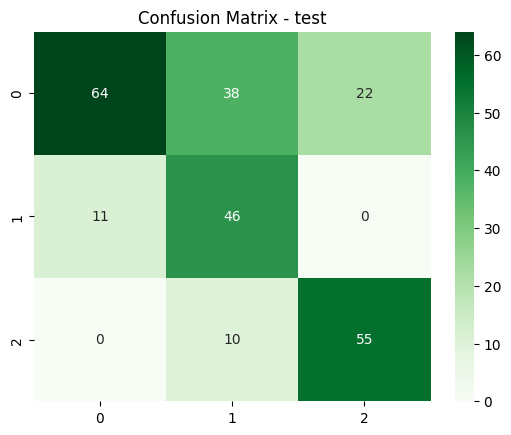

In [ ]:
print("\nConfusion Matrix train:")
sns.heatmap(confusion_matrix(y_test, y_test_predict_rf), annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix - test")
plt.show()

In [ ]:
print(metrics.classification_report(y_train,y_train_predict_rf))

              precision    recall  f1-score   support

           0       0.97      0.50      0.66       494
           1       0.71      0.98      0.82       494
           2       0.86      0.94      0.90       494

    accuracy                           0.81      1482
   macro avg       0.85      0.81      0.79      1482
weighted avg       0.85      0.81      0.79      1482



In [ ]:
print(metrics.classification_report(y_test,y_test_predict_rf))

              precision    recall  f1-score   support

           0       0.85      0.52      0.64       124
           1       0.49      0.81      0.61        57
           2       0.71      0.85      0.77        65

    accuracy                           0.67       246
   macro avg       0.69      0.72      0.68       246
weighted avg       0.73      0.67      0.67       246



#### Random Forest - Multiclass

One-vs-Rest (OvR)

In [ ]:
# Modelo base
rf_base = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

# Modelo OvR
ovr_rf = OneVsRestClassifier(rf_base)

In [ ]:
ovr_rf.fit(X_train, y_train)

OneVsRestClassifier(estimator=RandomForestClassifier(n_estimators=300,
                                                     n_jobs=-1,
                                                     random_state=42))

In [ ]:
y_train_pred_ovr_rf = ovr_rf.predict(X_train)
y_test_pred_ovr_rf  = ovr_rf.predict(X_test)

y_train_proba_ovr_rf = ovr_rf.predict_proba(X_train)
y_test_proba_ovr_rf  = ovr_rf.predict_proba(X_test)


Confusion Matrix train:


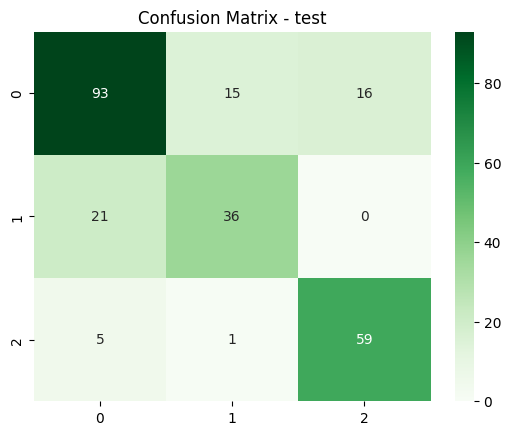

In [ ]:
print("\nConfusion Matrix train:")
sns.heatmap(confusion_matrix(y_test, y_test_pred_ovr_rf), annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix - test")
plt.show()

In [ ]:
print(metrics.classification_report(y_train,y_train_pred_ovr_rf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       494
           1       1.00      1.00      1.00       494
           2       1.00      1.00      1.00       494

    accuracy                           1.00      1482
   macro avg       1.00      1.00      1.00      1482
weighted avg       1.00      1.00      1.00      1482



In [ ]:
print(metrics.classification_report(y_test, y_test_pred_ovr_rf))

              precision    recall  f1-score   support

           0       0.78      0.75      0.77       124
           1       0.69      0.63      0.66        57
           2       0.79      0.91      0.84        65

    accuracy                           0.76       246
   macro avg       0.75      0.76      0.76       246
weighted avg       0.76      0.76      0.76       246



One-vs-One (OvO)

In [ ]:
# Modelo base
rf_base = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

# Modelo OvO
ovo_rf = OneVsOneClassifier(rf_base)

In [ ]:
ovo_rf.fit(X_train, y_train)

OneVsOneClassifier(estimator=RandomForestClassifier(n_estimators=300, n_jobs=-1,
                                                    random_state=42))

In [ ]:
y_train_pred_ovo_rf = ovo_rf.predict(X_train)
y_test_pred_ovo_rf  = ovo_rf.predict(X_test)


Confusion Matrix train:


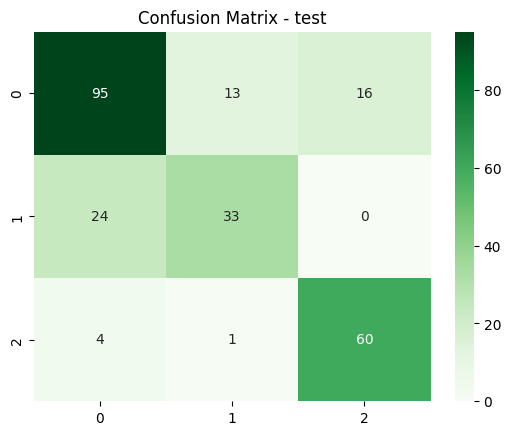

In [ ]:
print("\nConfusion Matrix train:")
sns.heatmap(confusion_matrix(y_test, y_test_pred_ovo_rf), annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix - test")
plt.show()

In [ ]:
print(metrics.classification_report(y_train, y_train_pred_ovo_rf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       494
           1       1.00      1.00      1.00       494
           2       1.00      1.00      1.00       494

    accuracy                           1.00      1482
   macro avg       1.00      1.00      1.00      1482
weighted avg       1.00      1.00      1.00      1482



In [ ]:
print(metrics.classification_report(y_test, y_test_pred_ovo_rf))

              precision    recall  f1-score   support

           0       0.77      0.77      0.77       124
           1       0.70      0.58      0.63        57
           2       0.79      0.92      0.85        65

    accuracy                           0.76       246
   macro avg       0.75      0.76      0.75       246
weighted avg       0.76      0.76      0.76       246



## Guardando los modelos para un uso posterior

In [ ]:
import pickle

In [ ]:
filename = '/gdrive/MyDrive/03. CURSOS/06. DMC - ADVANCED DATA SCIENCE/03. Aprendizaje supervisado multiclase/clase 02/DT_model.sav'
pickle.dump(DT, open(filename, 'wb'))

In [ ]:
filename = '/gdrive/MyDrive/03. CURSOS/06. DMC - ADVANCED DATA SCIENCE/03. Aprendizaje supervisado multiclase/clase 02/ovr_model_DT.sav'
pickle.dump(ovr_model, open(filename, 'wb'))